# Oversampling when the minority is scarce

The undersampling work (notebook 14, PR #19) showed that on large imbalanced data, resampling does not beat a properly class-corrected model, it only trains faster. Oversampling is meant for the **opposite** regime: *small* datasets where the minority has too few examples for the model to learn its shape. There the hope is that **synthesising** minority points (SMOTE and relatives) adds information that reweighting cannot recover, because no amount of reweighting invents the missing examples.

This notebook tests that hope on four datasets with a genuinely scarce minority (24-104 positives). For each dataset and learner (Random Forest, XGBoost) we compare `baseline`, `class_weight` (the Elkan-equivalent correction), and four oversamplers (`ros`, `smote`, `borderline`, `adasyn`). Every resampler is fit **inside** the cross-validation (imblearn `Pipeline`), so no synthetic point leaks into a validation fold. Performance is threshold-free (ROC-AUC and average precision) with dispersion from `RepeatedStratifiedKFold` (5 folds x 3 repeats).

**The question:** does synthesising minority points beat plain class weights when the minority is scarce, or does the Elkan equivalence hold even here?

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pickle.load(open(Path('..') / 'models' / 'oversampling-scarce' / 'results.pkl', 'rb'))
runs = results['runs']
synth_quality = results['meta']['synthetic_quality']

DATASETS = ['libras_move', 'spectrometer', 'ozone_level', 'secom']
METHODS = ['baseline', 'class_weight', 'ros', 'smote', 'borderline', 'adasyn']
n_pos = {'libras_move': 24, 'spectrometer': 45, 'ozone_level': 73, 'secom': 104}
print('runs:', len(runs))

runs: 48


## Results table

Mean +/- std over the 15 cross-validation folds. ROC-AUC and average precision (AP). AP is the metric that responds to the rare positives, so it is the one to watch.

In [2]:
def cell(run, metric):
    v = run[metric]
    return f'{v.mean():.3f}±{v.std():.3f}'

def table(metric):
    idx = pd.MultiIndex.from_product([DATASETS, ['rf', 'xgb']], names=['dataset', 'learner'])
    df = pd.DataFrame(index=idx, columns=METHODS, dtype=object)
    for r in runs:
        df.loc[(r['dataset'], r['learner']), r['method']] = cell(r, metric)
    return df

print('AVERAGE PRECISION (mean±std over 15 folds)')
table('average_precision')

AVERAGE PRECISION (mean±std over 15 folds)


baseline class_weight          ros        smote  \
dataset      learner                                                       
libras_move  rf       0.863±0.177  0.896±0.137  0.901±0.115  0.888±0.122   
             xgb      0.846±0.146  0.839±0.147  0.848±0.147  0.868±0.152   
spectrometer rf       0.911±0.077  0.898±0.079  0.898±0.077  0.906±0.085   
             xgb      0.916±0.052  0.886±0.078  0.878±0.070  0.877±0.070   
ozone_level  rf       0.307±0.114  0.349±0.091  0.339±0.086  0.308±0.092   
             xgb      0.293±0.067  0.299±0.073  0.314±0.093  0.345±0.108   
secom        rf       0.180±0.047  0.203±0.046  0.184±0.041  0.194±0.044   
             xgb      0.205±0.056  0.204±0.056  0.193±0.057  0.178±0.047   

                       borderline       adasyn  
dataset      learner                            
libras_move  rf       0.890±0.142  0.874±0.113  
             xgb      0.859±0.153  0.866±0.130  
spectrometer rf       0.902±0.078  0.894±0.073  
             xgb      0.879±0.067  0.898±0.059  
ozone_level  rf       0.304±0.079  0.303±0.090  
             xgb      0.329±0.093  0.348±0.099  
secom        rf       0.206±0.065  0.187±0.040  
             xgb      0.192±0.047  0.169±0.045

In [3]:
print('ROC-AUC (mean±std over 15 folds)')
table('roc_auc')

ROC-AUC (mean±std over 15 folds)


baseline class_weight          ros        smote  \
dataset      learner                                                       
libras_move  rf       0.979±0.035  0.978±0.035  0.981±0.027  0.976±0.038   
             xgb      0.945±0.064  0.939±0.071  0.944±0.068  0.934±0.079   
spectrometer rf       0.976±0.028  0.974±0.030  0.972±0.034  0.983±0.026   
             xgb      0.973±0.029  0.969±0.028  0.968±0.030  0.973±0.030   
ozone_level  rf       0.886±0.034  0.895±0.029  0.892±0.035  0.892±0.034   
             xgb      0.889±0.036  0.888±0.039  0.888±0.042  0.898±0.040   
secom        rf       0.717±0.053  0.744±0.037  0.736±0.046  0.742±0.051   
             xgb      0.698±0.060  0.711±0.056  0.702±0.047  0.684±0.052   

                       borderline       adasyn  
dataset      learner                            
libras_move  rf       0.978±0.036  0.975±0.032  
             xgb      0.944±0.077  0.939±0.070  
spectrometer rf       0.986±0.015  0.984±0.015  
             xgb      0.974±0.031  0.979±0.025  
ozone_level  rf       0.895±0.027  0.893±0.033  
             xgb      0.897±0.036  0.891±0.037  
secom        rf       0.731±0.067  0.744±0.051  
             xgb      0.695±0.059  0.689±0.054

## Figure 1 - oversampling vs class weights, per dataset

Average precision by method, with the `class_weight` result drawn as a horizontal reference line. If synthesising minority points genuinely helped, the SMOTE-family bars would clear that line. They do not: everywhere the oversamplers sit on top of the `class_weight` line, within the cross-validation error bars.

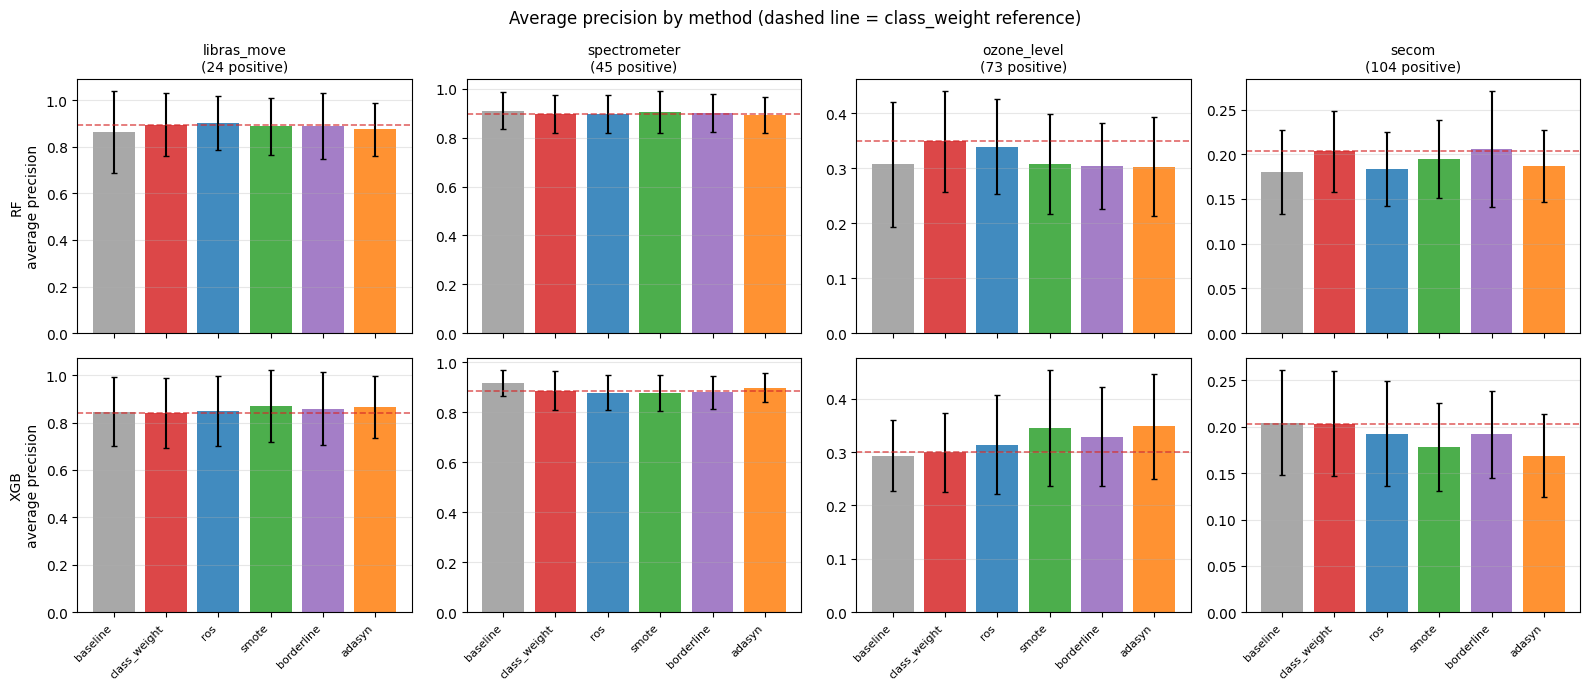

In [4]:
def get(dataset, learner, method, metric):
    for r in runs:
        if r['dataset'] == dataset and r['learner'] == learner and r['method'] == method:
            return r[metric].mean(), r[metric].std()
    return np.nan, np.nan

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
colors = {'baseline': '#999999', 'class_weight': '#d62728', 'ros': '#1f77b4',
          'smote': '#2ca02c', 'borderline': '#9467bd', 'adasyn': '#ff7f0e'}
for j, learner in enumerate(['rf', 'xgb']):
    for i, ds in enumerate(DATASETS):
        ax = axes[j, i]
        means = [get(ds, learner, m, 'average_precision')[0] for m in METHODS]
        errs = [get(ds, learner, m, 'average_precision')[1] for m in METHODS]
        ax.bar(range(len(METHODS)), means, yerr=errs, capsize=2,
               color=[colors[m] for m in METHODS], alpha=0.85)
        cw = get(ds, learner, 'class_weight', 'average_precision')[0]
        ax.axhline(cw, color='#d62728', ls='--', lw=1.2, alpha=0.7)
        ax.set_xticks(range(len(METHODS)))
        ax.set_xticklabels(METHODS, rotation=45, ha='right', fontsize=8)
        if i == 0:
            ax.set_ylabel(f'{learner.upper()}\naverage precision')
        if j == 0:
            ax.set_title(f'{ds}\n({n_pos[ds]} positive)', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
fig.suptitle('Average precision by method (dashed line = class_weight reference)', fontsize=12)
fig.tight_layout()
plt.show()

## Figure 2 - why SMOTE does or does not help: synthetic quality

For each dataset we trained a classifier to tell **real** minority points from **SMOTE-synthetic** ones (cross-validated AUC). An AUC near 0.5 means the synthetic points are indistinguishable from real, so SMOTE is interpolating cleanly inside the real manifold; an AUC near 1.0 means SMOTE is generating off-distribution points.

The x-axis below is that synthetic-quality AUC; the y-axis is how much SMOTE's average precision beats `class_weight` (averaged over RF and XGBoost). The pattern is the whole story: **SMOTE only ever ties class weights, and it does so only where its synthetic points are realistic.** Exactly in the high-dimensional, scarce-minority case it is marketed for (ozone_level, secom, AUC ~0.87), the synthetic points are off-distribution and SMOTE gives no lift, sometimes a small loss.

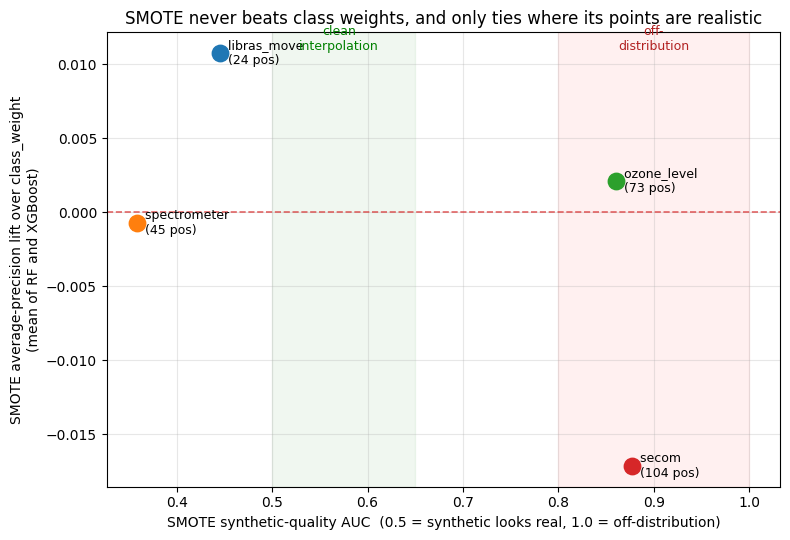

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for ds in DATASETS:
    sq = synth_quality[ds]
    lifts = []
    for learner in ['rf', 'xgb']:
        smote_ap = get(ds, learner, 'smote', 'average_precision')[0]
        cw_ap = get(ds, learner, 'class_weight', 'average_precision')[0]
        lifts.append(smote_ap - cw_ap)
    lift = np.mean(lifts)
    ax.scatter(sq, lift, s=140, zorder=3)
    ax.annotate(f'  {ds}\n  ({n_pos[ds]} pos)', (sq, lift), fontsize=9, va='center')
ax.axhline(0, color='#d62728', ls='--', lw=1.2, alpha=0.7)
ax.axvspan(0.5, 0.65, color='green', alpha=0.06)
ax.axvspan(0.8, 1.0, color='red', alpha=0.06)
ax.text(0.57, ax.get_ylim()[1] * 0.9, 'clean\ninterpolation', ha='center', fontsize=9, color='green')
ax.text(0.9, ax.get_ylim()[1] * 0.9, 'off-\ndistribution', ha='center', fontsize=9, color='#b22222')
ax.set_xlabel('SMOTE synthetic-quality AUC  (0.5 = synthetic looks real, 1.0 = off-distribution)')
ax.set_ylabel('SMOTE average-precision lift over class_weight\n(mean of RF and XGBoost)')
ax.set_title('SMOTE never beats class weights, and only ties where its points are realistic')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Conclusion

Oversampling was the strongest remaining case for resampling: small data, a scarce minority, and synthesis that reweighting cannot imitate. On threshold-free metrics the case does not hold.

1. **Class weights match or beat every oversampler on all four datasets.** On average precision (the metric that responds to the rare positives), no SMOTE variant clears the `class_weight` reference by more than the cross-validation noise; on `secom` with XGBoost, SMOTE is slightly worse than doing nothing.

2. **Where SMOTE helps at all is predicted by its synthetic quality.** When the synthetic points are indistinguishable from real (`spectrometer`, `libras_move`, AUC ~0.4), SMOTE is harmless and ties. When they are off-distribution (`ozone_level`, `secom`, AUC ~0.87, exactly the high-dimensional scarce-minority case it is sold for), SMOTE interpolates across a near-empty space and adds nothing. So the mechanism that is supposed to make oversampling special is precisely the one that fails when the minority is scarce.

3. **This extends the Elkan result to oversampling.** For undersampling the equivalence was calibration-and-threshold; here it is that the useful part of oversampling (rebalancing the classes' influence) is exactly what `class_weight` does directly, without the variance of synthesising points. The correction that matters is reweighting, not synthesis.

The practical rule stays simple: reach for class weights first. Oversampling is worth trying only on low-dimensional data where a real-vs-synthetic check confirms the synthetic points are realistic, and even then the upside over class weights is within noise.